# Gene chromatin analysis around replication

May 2, 2024

Plot the chromatin before and after replication fork passes through the gene.

**Goal:** Identify differences in chromatin when the fork passes through a gene. Identify different partitions of gene sets in which there may be patterns of differences (gene expression level, transcription vs replication direction, etc.)


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
repl_timing_file = 'datasets/computed_mnase/all_repl_timing_deconvolved.csv'
repl_timing = pd.read_csv(repl_timing_file).set_index('orf_name')
print(len(repl_timing), " genes with replication profiles")

repl_timing.head()


5250  genes with replication profiles


,timing,H_index
orf_name,,
YAL067W-A,53.314585,196
YAL067C,52.304185,194
YAL064C-A,52.809385,195
YAL064W,51.798985,193
YAL063C-A,51.798985,193


In [3]:
from src.replication_deconvolution_solver import plot_chrom_repl_timing_from_data

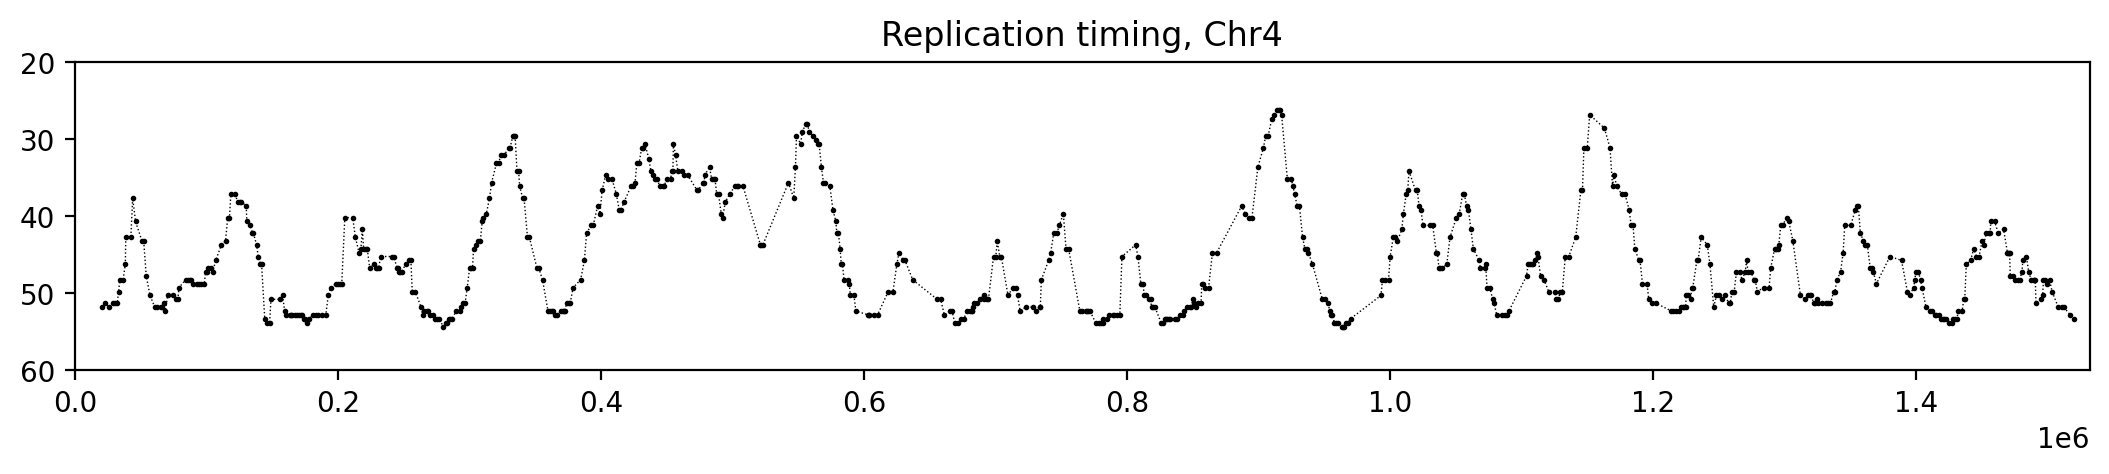

In [4]:
from src.geneset import get_deconvolved_geneset
geneset = get_deconvolved_geneset()

chrom = 4
plot_chrom_repl_timing_from_data(repl_timing, geneset, chrom)

In [5]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.026
1001/5574 - 00:00:05.808
2001/5574 - 00:00:11.996
3001/5574 - 00:00:18.204
4001/5574 - 00:00:24.614
5001/5574 - 00:00:30.787


In [6]:
promoter_analysis.correct_f_images_by_strand()

In [291]:
# Let's get the gene expression at the replication time.

from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()


# Which genes to start with?

Options:

Many genes, all genes compute the chromatin (some delta) before and after replication
- Prior-replication fork
- Post-replication fork

Early vs Late
High vs Low Gene expression


In [360]:
from src.gene_chromatin_replication_analysis import GeneChromatinReplicationAnalysis

gene_chrom_repl_analysis = GeneChromatinReplicationAnalysis(promoter_analysis,
                                                            ge_analysis,
                                                            repl_timing)

5232 genes with replication timing
Shape of the f images:  (5232, 227, 8, 25)


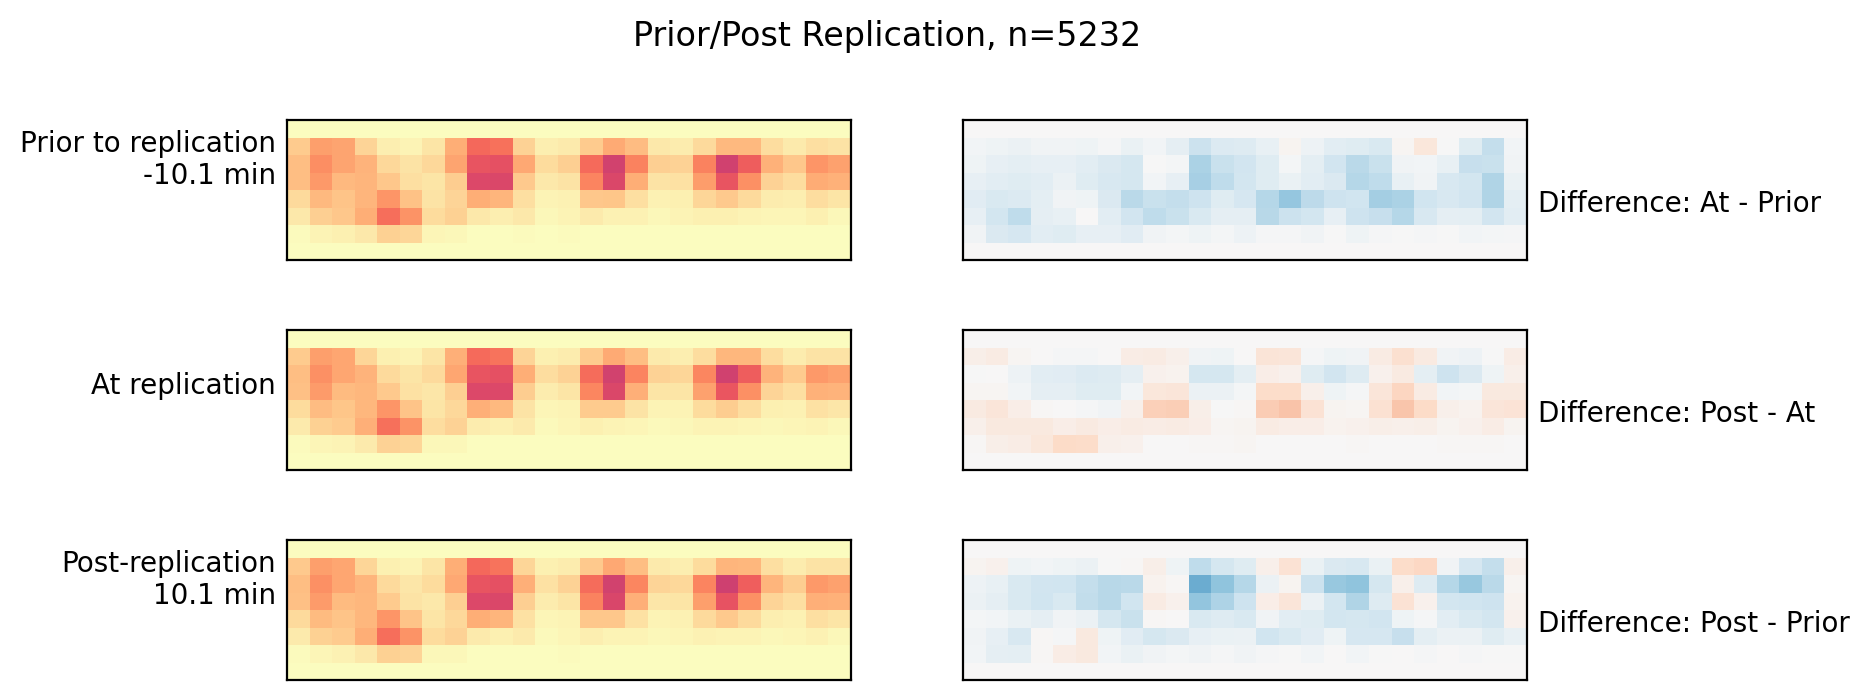

In [403]:
gene_chrom_repl_analysis.select_subset(delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images()

In [371]:
k = 500

sorted_genes_by_replication_exp = gene_chrom_repl_analysis.geneset_repl.\
    sort_values('expression_at_replication', ascending=False)
highly_expressed_orfs = sorted_genes_by_replication_exp.head(k).index.values.astype('str')
lowly_expressed_orfs = sorted_genes_by_replication_exp.tail(k).index.values.astype('str')

sorted_genes_by_replication_exp.head(5)

,gene,TSS,chr,strand,f_gene_index,replication_timing,replication_H_index,expression_at_replication
orf_name,,,,,,,,
YKL060C,FBA1,327512,11,-,2994,31.590485,153,18.741246
YHR174W,ENO2,451298,8,+,2296,40.179085,170,18.682895
YLR249W,YEF3,636741,12,+,3404,39.673885,169,18.653157
YOR063W,RPL3,444665,15,+,4559,36.642585,163,18.131134
YCR012W,PGK1,137707,3,+,510,40.684285,171,18.080586


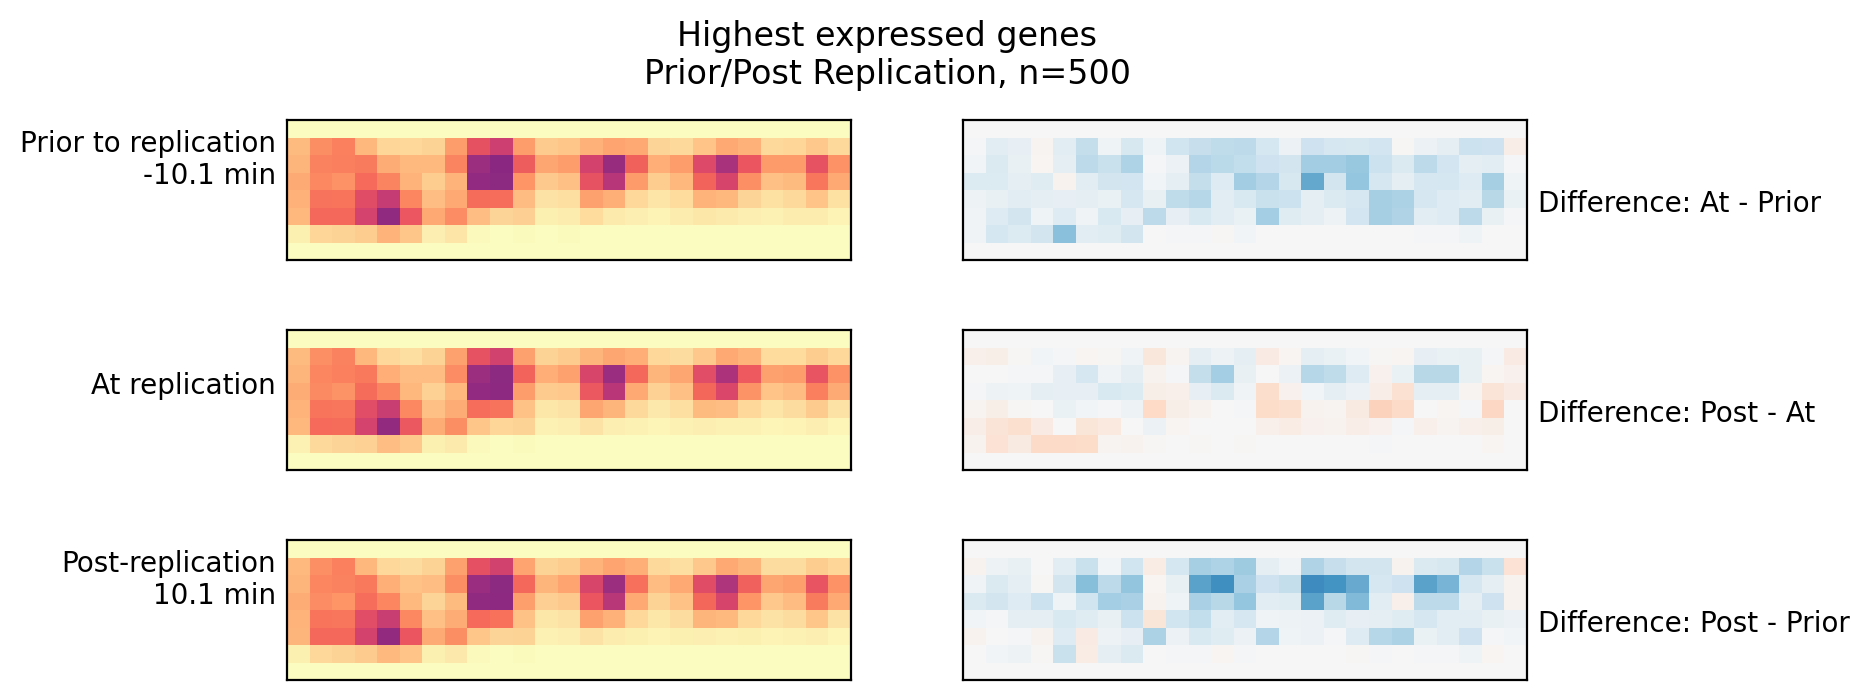

In [413]:
gene_chrom_repl_analysis.select_subset(subset_orfs=highly_expressed_orfs, delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images(title="Highest expressed genes")

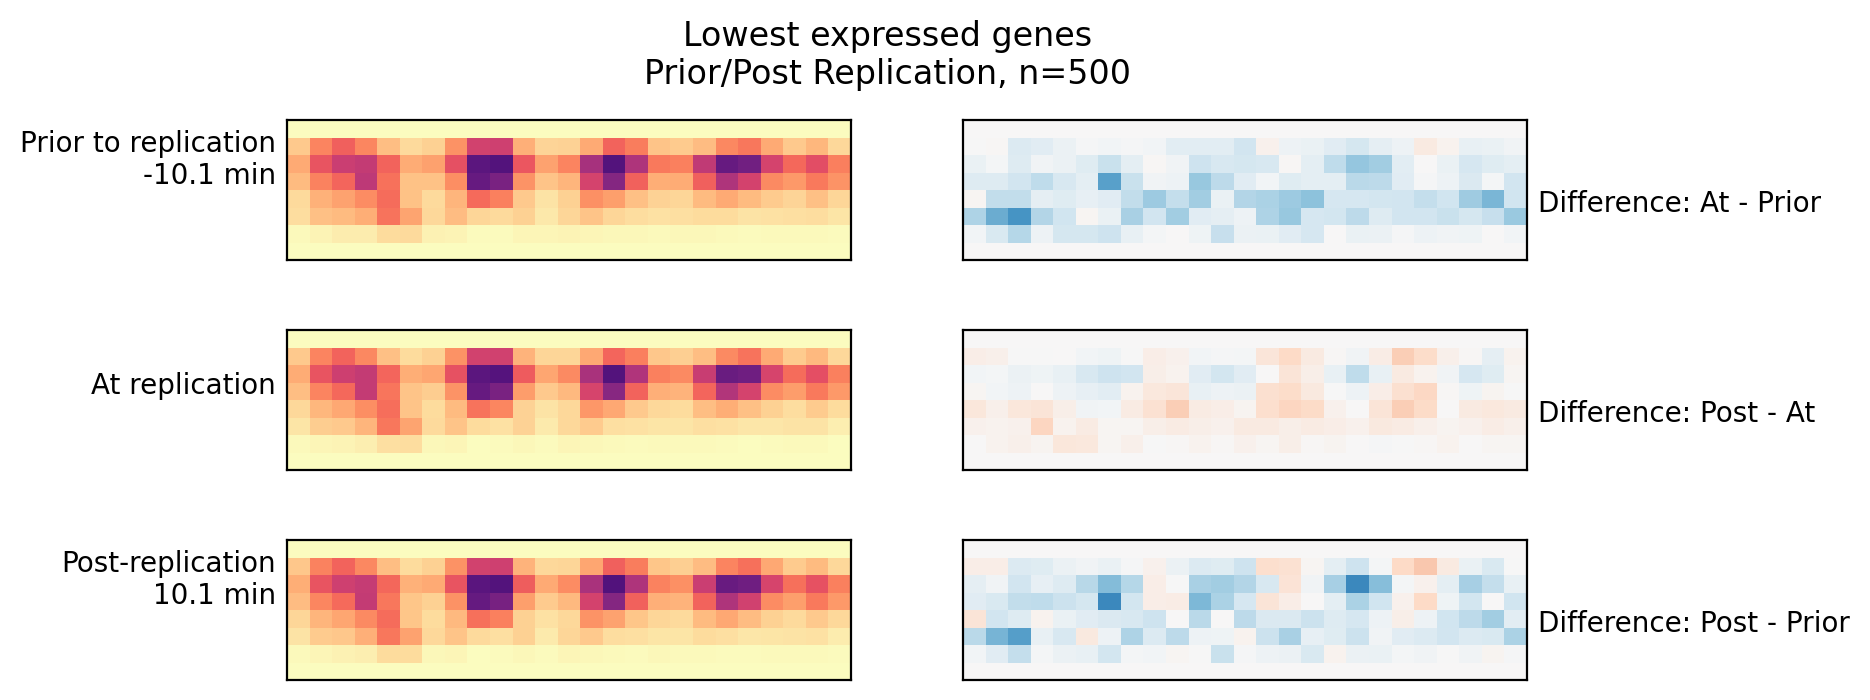

In [414]:
gene_chrom_repl_analysis.select_subset(subset_orfs=lowly_expressed_orfs, delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images(title="Lowest expressed genes")